# CSCI 114 O - Lab2: Unsupervised Learning — PCA and Autoencoder Feature Representations 

### Submitted by:
- Capistrano, Edrian Miguel
- Labariento, Gabriel Matthew
- Terrobias, John Kyrk

## Overview

The dataset we will use is the [Stroke Prediction Dataset] (https://www.kaggle.com/datasets/mobeenfatimah/stroke-risk-prediction-dataset). It has 50,000 records and 40 columns including the target `Stroke_Risk`, `Patient_ID`, `Stroke_Risk_Score` (leaks the target), `AI_Health_Recommendation`, and `Doctor_Consultation_Needed`. These columns will be dropped, leaving 35 input features for the model. The target variable here is Stroke_Risk which has the possible values Low, Moderate, and High. 

In [1]:
from copy import deepcopy
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

### Importing the data

In [2]:
DATA_URL = "stroke_risk_prediction_dataset.csv"
data = pd.read_csv(DATA_URL)

print("Dataset shape:", data.shape)
display(data.head())

Dataset shape: (50000, 40)


,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Heart_Rate,...,Medication_Adherence,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Work_Type,Residence_Type,Air_Pollution_Exposure,Stroke_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Stroke_Risk
0,1,80.0,Male,China,145.2,69.3,32.9,112,82,109,...,Excellent,NaN,79.0,Retired,Urban,High,47,Exercise Regularly,Yes,Moderate
1,2,37.0,Female,United Kingdom,188.6,110.8,31.1,137,76,59,...,Average,0.6,48.0,Student,Rural,Medium,40,Improve Diet Quality,Yes,Moderate
2,3,85.0,Female,Germany,175.5,103.7,33.7,108,105,89,...,Poor,1.7,114.0,Private,Rural,Medium,76,Monitor Blood Glucose Daily,Yes,High
3,4,44.0,Other,Brazil,161.3,50.2,19.3,126,73,88,...,Poor,1.5,101.0,Retired,Rural,Low,40,Exercise Regularly,Yes,Moderate
4,5,52.0,Female,United States,162.8,103.6,39.1,115,60,70,...,Average,7.1,55.0,Government,Rural,Medium,38,Monitor Blood Pressure,Yes,Moderate


### What do the columns mean?

1. `Patient_ID` — unique identifier assigned to each patient
2. `Age` — age of patient in years
3. `Gender` — biological gender of the patient (Male, Female, or Other)
4. `Country` — country where the patient is assumed to reside
5. `Height_cm` — patient’s height in centimeters
6. `Weight_kg` — patient’s body weight in kilograms
7. `BMI` — patient’s Body Mass Index calculated via height and weight
8. `Blood_Pressure_Systolic` — in mmHg, represents the pressure during heart contraction
9. `Blood_Pressure_Diastolic` — in mmHg, represents the pressure when the heart is at rest between beats
10. `Heart_Rate` — resting heart rate in beats per minute
11. `Blood_Glucose` — patient’s blood glucose levels measured in mg/dL
12. `HbA1c` — also known as glycated hemoglobin, measures the blood glucose level over the past two to three months
13. `Total_Cholesterol` — the total concentration of cholesterol in the blood
14. `HDL` — the blood concentration of high-density lipoprotein cholesterol, commonly called “good” cholesterol
15. `LDL` — the blood concentration of low-density lipoprotein cholesterol, commonly called “bad” cholesterol
16. `Triglycerides` — the concentration of triglycerides, a type of fat, in the blood
17. `Smoking_Status` — the patient’s smoking history, categorized as Never, Former, or Current
18. `Alcohol_Consumption` — the patient’s alcohol consumption frequency: Never, Occasionally, or Frequently
19. `Physical_Activity_Level` — the patient’s overall physical activity level, categorized as Low, Moderate, or High
20. `Sleep_Hours` — the patient’s daily sleep duration in hours
21. `Stress_Level` — the patient’s stress level, categorized as Low, Moderate, or High
22. `Diet_Quality` — the patient’s diet quality, categorized as Poor, Average, or Healthy
23. `Family_History_Stroke` — indicates whether the patient has a family history of stroke
24. `Family_History_Heart_Disease` — indicates whether the patient has a family history of heart disease
25. `Diabetes` — indicates whether the patient has diabetes
26. `Hypertension` — indicates whether the patient has hypertension, or persistently high blood pressure
27. `Heart_Disease` — indicates whether the patient has heart disease
28. `Previous_TIA` — indicates whether the patient has experienced a transient ischemic attack, a temporary interruption of blood flow to the brain
29. `Atrial_Fibrillation` — indicates whether the patient has atrial fibrillation, an irregular heart rhythm
30. `Chronic_Kidney_Disease` — indicates whether the patient has chronic kidney disease
31. `Medication_Adherence` — the patient’s adherence to prescribed medication, rated as Poor, Average, or Excellent
32. `Exercise_Hours_Per_Week` — the number of hours the patient exercises per week
33. `Daily_Walking_Minutes` — the number of minutes the patient walks per day
34. `Work_Type` — the patient’s employment category: Private, Government, Self-Employed, Retired, or Student
35. `Residence_Type` — indicates whether the patient lives in an Urban or Rural area
36. `Air_Pollution_Exposure` — the patient’s air pollution exposure level, categorized as Low, Medium, or High
37. `Stroke_Risk_Score` — a generated numerical score representing the patient’s estimated stroke risk
38. `AI_Health_Recommendation` — an AI-generated health recommendation associated with the patient’s record
39. `Doctor_Consultation_Needed` — indicates whether a doctor’s consultation is recommended
40. `Stroke_Risk` — the target variable classifying stroke risk as Low, Moderate, or High


Dimensionality reduction may be useful for this dataset because there are several feaatures that already overlap like those measuring the patient's body size, physical activity, blood glucose, blood pressure, and cholesterol. The names and descriptions alone suggest possible redundancy, but we need further analysis to confirm this.

### Dropping unnecessary columns

We drop columns the coumns `Patient_ID`, `Stroke_Risk_Score`, `AI_Health_Recommendation`, and `Doctor_Consultation_Needed` as these may not be needed as inputs to the model. `Patient_ID` is simply the patient identifier, `Stroke_Risk_Score` may leak the target, while `AI_Health_Recommendation` and `Doctor_Consultation_Needed` may also reflect the score or risk classification. Because their generation process is unclear, we exclude them as a precaution against target leakage.

In [3]:
data = data.drop(columns=['Patient_ID', 'Stroke_Risk_Score', 'AI_Health_Recommendation', 'Doctor_Consultation_Needed'])

### Splitting the data


We use a 70%/15%/15% training/validation/testing partition: 35,000/7,500/7,500 rows. This leaves most of the data for training and enough for model selection and testing. We use an integer validation size to avoid rounding errors and stratify by the target to keep the class proportions in every partition. Below, we check each partition's input and target row counts and report the training class proportions.

In [4]:
TARGET_COLUMN = 'Stroke_Risk'
CLASS_NAMES = ["Low", "Moderate", "High"]
CLASS_TO_INDEX = {name: index for index, name in enumerate(CLASS_NAMES)}

X = data.drop(columns=[TARGET_COLUMN])
y = data[TARGET_COLUMN]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=len(X_test), stratify=y_train_val, random_state=SEED
)

print("Training rows:  ", len(X_train))
print("Validation rows:", len(X_val))
print("Test rows:      ", len(X_test))

print("Training row lengths match: " + str(len(X_train) == len(y_train)))
print("Validation row lengths match: " + str(len(X_val) == len(y_val)))
print("Test row lengths match: " + str(len(X_test) == len(y_test)))
print()
print("Training class proportions:")
print(y_train.value_counts(normalize=True).reindex(CLASS_NAMES))


Training rows:   35000
Validation rows: 7500
Test rows:       7500
Training row lengths match: True
Validation row lengths match: True
Test row lengths match: True

Training class proportions:
Stroke_Risk
Low         0.070257
Moderate    0.687514
High        0.242229
Name: proportion, dtype: float64


# Data Preprocessing

### Missing Values and Class Distribution

Missing values: 13522


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,49781.0,NaN,NaN,NaN,53.903096,21.070953,18.0,36.0,54.0,72.0,90.0
Gender,50000,3,Other,16791,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,50000,25,Italy,2058,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Height_cm,48475.0,NaN,NaN,NaN,170.125582,14.484573,145.0,157.6,170.1,182.8,195.0
Weight_kg,48477.0,NaN,NaN,NaN,87.506141,24.56549,45.0,66.2,87.5,108.8,130.0
BMI,50000.0,NaN,NaN,NaN,30.901386,10.25456,11.9,22.7,30.1,37.8,61.5
Blood_Pressure_Systolic,50000.0,NaN,NaN,NaN,135.06142,20.526562,100.0,117.0,135.0,153.0,170.0
Blood_Pressure_Diastolic,50000.0,NaN,NaN,NaN,84.84062,14.685149,60.0,72.0,85.0,98.0,110.0
Heart_Rate,50000.0,NaN,NaN,NaN,82.52102,16.141082,55.0,68.0,83.0,97.0,110.0
Blood_Glucose,49040.0,NaN,NaN,NaN,145.031421,43.405484,70.0,107.4,145.1,182.7,220.0


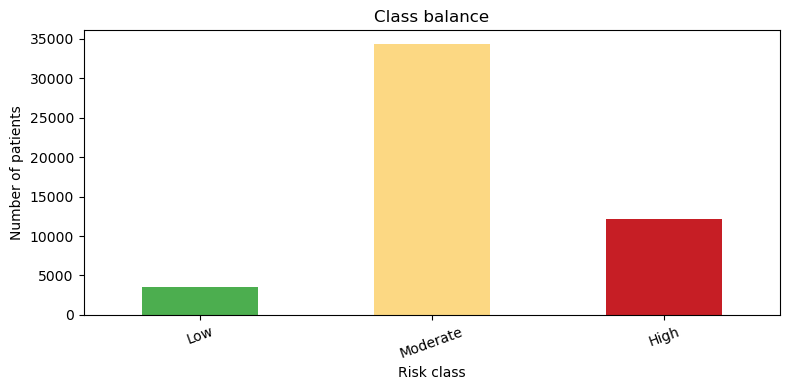

In [5]:
print("Missing values:", int(data.isna().sum().sum()))
display(data.describe(include="all").T)

plt.figure(figsize=(8, 4))

data["Stroke_Risk"].value_counts().reindex(
    ["Low", "Moderate", "High"]
).plot(kind="bar", color=["#4cae4f", "#FCD883", "#C61E25"])
plt.title("Class balance")
plt.xlabel("Risk class")
plt.ylabel("Number of patients")
plt.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

There are `13,522` missing values in the dataset. We use the median-value imputation on numerical columns with missing features.  

In [6]:
numeric_cols = X_train.select_dtypes(include="number").columns
medians = X_train[numeric_cols].median()

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

X_train[numeric_cols] = X_train[numeric_cols].fillna(medians)
X_val[numeric_cols] = X_val[numeric_cols].fillna(medians)
X_test[numeric_cols] = X_test[numeric_cols].fillna(medians)

In [7]:
print("Missing values:", int(X_train[numeric_cols].isna().sum().sum()))
print("Missing values:", int(X_val[numeric_cols].isna().sum().sum()))
print("Missing values:", int(X_test[numeric_cols].isna().sum().sum()))

Missing values: 0
Missing values: 0
Missing values: 0


In [8]:
# Select only columns with categorical dtype
categorical_cols = X_train.select_dtypes(include=['object', 'string', 'category']).columns
missing = X_train[categorical_cols].isna().sum()
display(missing[missing > 0])


Medication_Adherence    754
dtype: int64

We see that in our training data, only the `Medication_Adherence` column has missing values. We use "Missing" to impute the missing values in this column.

In [9]:
column = "Medication_Adherence"

for frame in (X_train, X_val, X_test):
    frame[column] = frame[column].fillna("Missing")

print("Missing training categorical values: ", X_train[categorical_cols].isna().sum().sum())
print("Missing validation categorical values: ", X_val[categorical_cols].isna().sum().sum())
print("Missing test categorical values: ", X_test[categorical_cols].isna().sum().sum())

Missing training categorical values:  0
Missing validation categorical values:  0
Missing test categorical values:  0


### One-hot encoding and Scaling

We standardize numerical columns so differences in units do not dominate the models. We one-hot encode categorical columns because assigning category numbers could imply an order. We keep these indicators at 0/1 so rare categories do not get larger weights from standardization. This gives numerical features more variance per column, which can affect what PCA and the autoencoder preserve. We fit both transformations on the training set only.

In [10]:
numeric_scaler = StandardScaler()
category_encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore",
    dtype=np.float32
)

numeric_scaler.fit(X_train[numeric_cols])
category_encoder.fit(X_train[categorical_cols])

def transform_features(frame):
    numeric_values = numeric_scaler.transform(frame[numeric_cols])
    categorical_values = category_encoder.transform(frame[categorical_cols])
    return np.hstack([numeric_values, categorical_values]).astype(np.float32)

X_train_processed = transform_features(X_train)
X_val_processed = transform_features(X_val)
X_test_processed = transform_features(X_test)

encoded_category_names = category_encoder.get_feature_names_out(
    categorical_cols
).tolist()
feature_names = numeric_cols.to_list() + encoded_category_names

print("One-hot encoded values:")
display(
    pd.DataFrame(
        category_encoder.transform(X_train[categorical_cols].head()),
        columns=encoded_category_names,
    )
)
print("Model input shape:", X_train_processed.shape)
print("Model feature names:", feature_names)

One-hot encoded values:


,Gender_Female,Gender_Male,Gender_Other,Country_Australia,Country_Bangladesh,Country_Brazil,Country_Canada,Country_China,Country_France,Country_Germany,...,Work_Type_Government,Work_Type_Private,Work_Type_Retired,Work_Type_Self-Employed,Work_Type_Student,Residence_Type_Rural,Residence_Type_Urban,Air_Pollution_Exposure_High,Air_Pollution_Exposure_Low,Air_Pollution_Exposure_Medium
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


Model input shape: (35000, 89)
Model feature names: ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Heart_Rate', 'Blood_Glucose', 'HbA1c', 'Total_Cholesterol', 'HDL', 'LDL', 'Triglycerides', 'Sleep_Hours', 'Exercise_Hours_Per_Week', 'Daily_Walking_Minutes', 'Gender_Female', 'Gender_Male', 'Gender_Other', 'Country_Australia', 'Country_Bangladesh', 'Country_Brazil', 'Country_Canada', 'Country_China', 'Country_France', 'Country_Germany', 'Country_India', 'Country_Indonesia', 'Country_Italy', 'Country_Japan', 'Country_Malaysia', 'Country_Mexico', 'Country_Nigeria', 'Country_Pakistan', 'Country_Russia', 'Country_Saudi Arabia', 'Country_Singapore', 'Country_South Africa', 'Country_South Korea', 'Country_Spain', 'Country_Turkey', 'Country_UAE', 'Country_United Kingdom', 'Country_United States', 'Smoking_Status_Current', 'Smoking_Status_Former', 'Smoking_Status_Never', 'Alcohol_Consumption_Frequently', 'Alcohol_Consumption_Never', 'Alcohol_Consu

In [11]:
def one_hot_targets(frame):
    class_indices = torch.tensor(
        frame.map(CLASS_TO_INDEX).to_numpy(),
        dtype=torch.long,
    )
    return F.one_hot(
        class_indices,
        num_classes=len(CLASS_NAMES),
    ).to(torch.float32)


y_train_processed = one_hot_targets(y_train)
y_validation_processed = one_hot_targets(y_val)
y_test_processed = one_hot_targets(y_test)

sample_labels = y_train.iloc[:5]

target_demo = pd.DataFrame({
    "original_label": sample_labels.to_numpy(),
    "class_index": sample_labels.map(CLASS_TO_INDEX).to_numpy(),
    "one_hot_vector": y_train_processed[:5].tolist(),
})

display(target_demo)

print(
    "Each one-hot row sums to:",
    y_train_processed[:5].sum(dim=1).tolist(),
)

,original_label,class_index,one_hot_vector
0,Moderate,1,"[0.0, 1.0, 0.0]"
1,High,2,"[0.0, 0.0, 1.0]"
2,Moderate,1,"[0.0, 1.0, 0.0]"
3,High,2,"[0.0, 0.0, 1.0]"
4,Moderate,1,"[0.0, 1.0, 0.0]"


Each one-hot row sums to: [1.0, 1.0, 1.0, 1.0, 1.0]


### Defining n and choosing k

After preprocessing, we now have 89 input features `n`. Now, we choose candidate dimensions for `k`, which represents the number of features in the compressed representation. Each candidate `k` must satisfy `1 <= k < n`.

In [12]:
n = X_train_processed.shape[1]
candidate_dimensions = [2, 15, 45, 70]
print("n =", n)
print("Candidate Dimensions:", candidate_dimensions)

n = 89
Candidate Dimensions: [2, 15, 45, 70]


## Building a Classifier